### imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv('../data/urban_development_dataset.csv')

In [3]:
def load_and_examine(df):
    """Initial data examination"""
    print("Dataset Shape:", df.shape)
    print("\nMissing Values:\n", df.isnull().sum())
    print("\nData Types:\n", df.dtypes)
    return df.describe()

In [4]:
load_and_examine(df)

Dataset Shape: (10000, 22)

Missing Values:
 population_density               500
median_age                       500
average_household_income         500
number_of_schools                500
number_of_hospitals              500
number_of_parks                  500
public_transport_availability    500
unemployment_rate                500
retail_density                   500
office_space_availability        500
green_space_percentage           500
average_temperature              500
air_quality_index                500
crime_rate_per_1000              500
fire_station_proximity           500
proximity_to_highways            500
internet_speed                   500
housing_price_index              500
year                             500
road_density                     500
urban_area_type                    0
development_trend_score            0
dtype: int64

Data Types:
 population_density               float64
median_age                       float64
average_household_income        

,population_density,median_age,average_household_income,number_of_schools,number_of_hospitals,number_of_parks,public_transport_availability,unemployment_rate,retail_density,office_space_availability,...,average_temperature,air_quality_index,crime_rate_per_1000,fire_station_proximity,proximity_to_highways,internet_speed,housing_price_index,year,road_density,development_trend_score
count,9500.000000,9500.000000,9.500000e+03,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,...,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000
mean,4991.625970,35.279457,6.010906e+04,4.991474,1.982632,3.040842,0.496868,5.018623,50.073169,50109.607293,...,14.974232,51.040598,46.791214,5.036543,10.062984,50.134666,99.959800,2019.996421,49.871433,2.988700
std,1994.854691,9.568304,5.955652e+04,2.227845,1.394126,1.740090,0.287572,1.989349,19.264134,28681.503160,...,10.081082,20.016145,20.024942,2.883472,5.751247,19.796671,19.825338,1.416440,20.542146,1.096491
min,100.000000,18.000000,1.000000e+04,0.000000,0.000000,0.000000,0.000005,0.000000,5.000000,1004.818332,...,-24.517435,0.059818,-7.033524,0.000569,0.003901,1.000000,50.000000,2018.000000,-14.435687,1.000000
25%,3640.128794,28.368903,4.129131e+04,3.000000,1.000000,2.000000,0.249202,3.661788,36.888167,25167.483746,...,8.351723,37.379888,32.924224,2.585283,5.094561,36.550765,86.492808,2019.000000,36.077935,2.000000
50%,4984.830208,35.116940,5.511348e+04,5.000000,2.000000,3.000000,0.498003,5.030404,49.714772,50153.479286,...,14.913318,51.174239,46.518978,5.030731,10.156343,49.912599,99.688797,2020.000000,49.749942,3.000000
75%,6330.058011,41.842575,6.874788e+04,6.000000,3.000000,4.000000,0.739598,6.365608,62.785223,75063.433245,...,21.720647,64.521308,60.544726,7.546573,15.118761,63.506120,113.329764,2021.000000,63.572478,4.000000
max,12852.475413,79.790843,1.035413e+06,17.000000,12.000000,11.000000,0.999983,13.596557,129.610619,99997.527825,...,54.493777,136.233626,127.843821,9.998760,19.998216,122.007397,165.906697,2022.000000,132.515683,5.000000


In [5]:
display(df.dtypes)

population_density               float64
median_age                       float64
average_household_income         float64
number_of_schools                float64
number_of_hospitals              float64
number_of_parks                  float64
public_transport_availability    float64
unemployment_rate                float64
retail_density                   float64
office_space_availability        float64
green_space_percentage           float64
average_temperature              float64
air_quality_index                float64
crime_rate_per_1000              float64
fire_station_proximity           float64
proximity_to_highways            float64
internet_speed                   float64
housing_price_index              float64
year                             float64
road_density                     float64
urban_area_type                   object
development_trend_score            int64
dtype: object

In [6]:
display(df.info)

<bound method DataFrame.info of       population_density  median_age  average_household_income  \
0            5993.428306   28.215053              61965.724953   
1            4723.471398         NaN                       NaN   
2            6295.377076   29.026189              36269.603084   
3            8046.059713   36.104180              66591.684435   
4            4531.693251   46.971785              25198.346488   
...                  ...         ...                       ...   
9995         7602.204126   38.878273              43454.242988   
9996         1003.310066   48.773666              83892.079667   
9997         3589.366552   38.783540              44972.653689   
9998         5991.531146   52.135297              17152.863510   
9999         6288.776907   18.800802              50422.315822   

      number_of_schools  number_of_hospitals  number_of_parks  \
0                   5.0                  2.0              3.0   
1                   4.0                  0.0 

In [7]:
# Data preprocessing
def preprocess_data(df):
    # Handle categorical data
    le = LabelEncoder()
    df['urban_area_type_encoded'] = le.fit_transform(df['urban_area_type'])
    
    # Store mapping for reference
    urban_type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Urban Type Mapping:", urban_type_mapping)
    
    return df

In [8]:
preprocess_data(df)

Urban Type Mapping: {'Commercial': 0, 'Industrial': 1, 'Mixed': 2, 'Residential': 3}


,population_density,median_age,average_household_income,number_of_schools,number_of_hospitals,number_of_parks,public_transport_availability,unemployment_rate,retail_density,office_space_availability,...,crime_rate_per_1000,fire_station_proximity,proximity_to_highways,internet_speed,housing_price_index,year,road_density,urban_area_type,development_trend_score,urban_area_type_encoded
0,5993.428306,28.215053,61965.724953,5.0,2.0,3.0,NaN,7.861705,37.189497,88712.383725,...,41.802960,6.402334,17.249894,77.988714,90.010909,2020.0,55.745540,Industrial,4,1
1,4723.471398,NaN,NaN,4.0,0.0,3.0,NaN,5.083094,46.340402,3626.311603,...,39.794477,3.560183,12.198698,46.044637,100.535265,2021.0,44.268702,Mixed,4,2
2,6295.377076,29.026189,36269.603084,NaN,2.0,0.0,0.247585,4.089341,31.838015,49082.549371,...,49.022339,5.456112,16.765462,34.875393,136.993995,2020.0,73.174815,Mixed,5,2
3,8046.059713,36.104180,66591.684435,5.0,2.0,0.0,0.993784,NaN,64.489689,30025.861163,...,30.998953,9.443431,18.425252,71.182735,89.952283,2019.0,79.516600,Industrial,2,1
4,4531.693251,46.971785,25198.346488,6.0,0.0,0.0,0.838243,6.676002,48.426125,NaN,...,39.880218,8.398393,15.101962,108.795957,64.845688,2018.0,47.145522,Industrial,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,7602.204126,38.878273,43454.242988,3.0,2.0,5.0,0.994162,4.603601,46.090046,16840.109019,...,58.211731,5.480902,3.785844,52.448271,89.995662,2018.0,81.199993,Mixed,3,2
9996,1003.310066,48.773666,83892.079667,5.0,2.0,1.0,0.598535,6.587076,NaN,48624.813230,...,31.287155,1.199461,0.494807,44.945071,105.209326,2020.0,10.920935,Residential,2,3
9997,3589.366552,38.783540,44972.653689,8.0,0.0,2.0,0.146678,7.304828,48.843829,6860.431416,...,44.530012,0.742477,11.758057,34.859604,94.287844,2021.0,26.466953,Mixed,2,2
9998,5991.531146,52.135297,17152.863510,9.0,0.0,3.0,0.444265,11.456558,39.510614,30224.201658,...,36.317356,NaN,19.602108,33.005368,116.261380,2020.0,69.757495,Mixed,3,2


In [9]:
# Visualizations
def plot_analysis(df):
    # Development trend distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='development_trend_score')
    plt.title('Development Trend Distribution')
    plt.show()
    
    # Urban area types vs development score
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='urban_area_type', y='development_trend_score')
    plt.xticks(rotation=45)
    plt.title('Development Score by Urban Area Type')
    plt.show()
    
    # Correlation analysis (excluding original categorical column)
    numeric_df = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(8, 4))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlations')
    plt.tight_layout()
    plt.show()


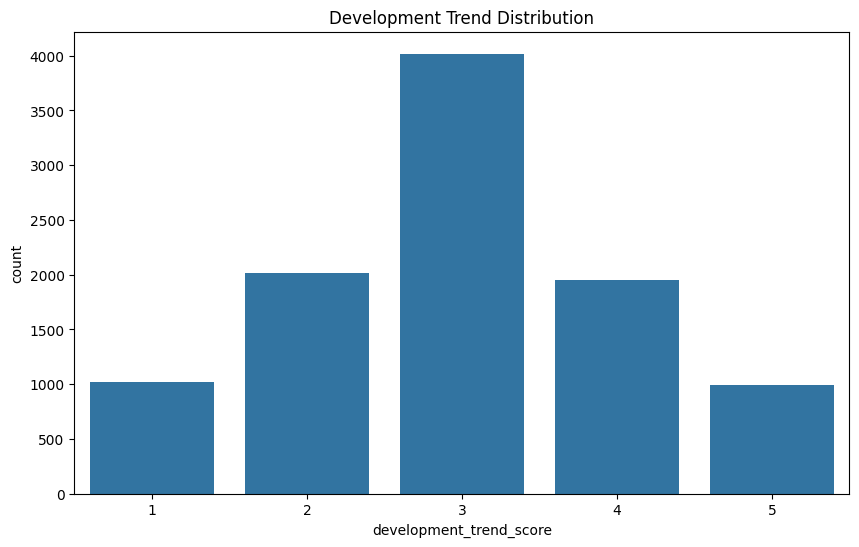

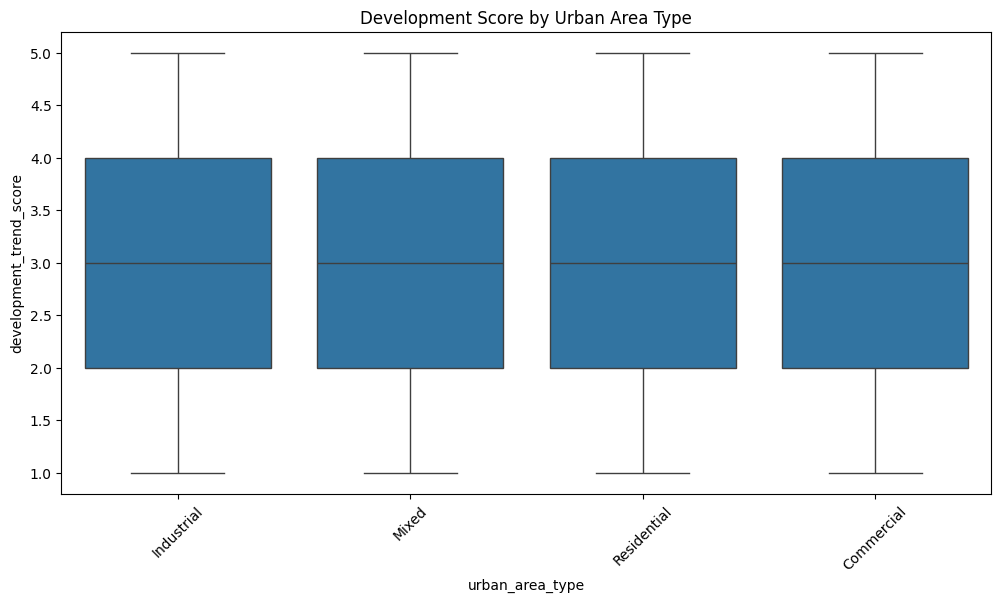

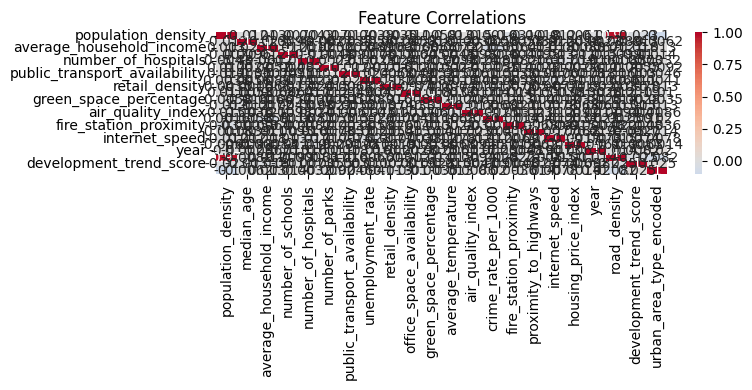

In [10]:
plot_analysis(df)

In [11]:
def identify_outliers(df):
    """Identify outliers using IQR method"""
    outliers = {}
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        outliers[column] = df[column][(df[column] < (Q1 - 1.5 * IQR)) | 
                                    (df[column] > (Q3 + 1.5 * IQR))].count()
    return pd.Series(outliers)

In [12]:
outliers = identify_outliers(df)

In [13]:
print('outliers : ')
print(outliers)

outliers : 
population_density                40
median_age                        35
average_household_income         118
number_of_schools                137
number_of_hospitals               49
number_of_parks                  121
public_transport_availability      0
unemployment_rate                 34
retail_density                    41
office_space_availability          0
green_space_percentage             0
average_temperature               78
air_quality_index                 34
crime_rate_per_1000               24
fire_station_proximity             0
proximity_to_highways              0
internet_speed                    38
housing_price_index               31
year                               0
road_density                      52
development_trend_score            0
urban_area_type_encoded            0
dtype: int64


In [14]:
def analyze_features(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    correlations = df[numeric_cols].corr()['development_trend_score'].sort_values(ascending=False)
    print("\nTop Feature Correlations with Development Score:")
    print(correlations)

In [15]:
analyze_features(df)


Top Feature Correlations with Development Score:
development_trend_score          1.000000
urban_area_type_encoded          0.025337
average_temperature              0.014999
unemployment_rate                0.010559
year                             0.008170
retail_density                   0.007755
internet_speed                   0.007435
number_of_parks                  0.005493
public_transport_availability    0.002982
green_space_percentage           0.002804
proximity_to_highways            0.002705
office_space_availability        0.001918
air_quality_index               -0.004138
fire_station_proximity          -0.004794
housing_price_index             -0.006288
number_of_hospitals             -0.007311
crime_rate_per_1000             -0.009144
number_of_schools               -0.010454
median_age                      -0.012734
average_household_income        -0.017952
population_density              -0.022860
road_density                    -0.024521
Name: development_trend_sc

In [16]:
# Load the data
train_df =pd.read_csv('../data/urban_development_dataset.csv') # Replace with your file path



In [17]:
test_df =pd.read_csv('../data/urban_development_test_data.csv') # Replace with your file path


In [18]:
class EnhancedUrbanModel:
    def __init__(self):
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.model = xgb.XGBClassifier(
            max_depth=7,
            learning_rate=0.05,
            n_estimators=1500,
            objective='multi:softmax',
            num_class=5,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3
        )
        
    def create_features(self, df):
        # Infrastructure density
        df['infrastructure_density'] = (df['number_of_schools'] + 
                                      df['number_of_hospitals'] + 
                                      df['number_of_parks']) / 3
        
        # Accessibility score
        df['accessibility_score'] = (df['public_transport_availability'] * 0.6 + 
                                   df['proximity_to_highways'] * 0.4)
        
        # Economic vitality
        df['economic_vitality'] = ((1 - df['unemployment_rate']) * 
                                 (df['retail_density'] + df['office_space_availability']))
        
        # Quality of life
        df['quality_of_life'] = (df['green_space_percentage'] * 0.3 + 
                                (100 - df['crime_rate_per_1000']) * 0.4 +
                                df['air_quality_index'] * 0.3)
        
        # Growth potential
        df['growth_potential'] = (df['housing_price_index'] * 0.4 + 
                                df['internet_speed'] * 0.3 +
                                df['population_density'] * 0.3)
        
        return df

    def handle_outliers(self, df):
        df_clean = df.copy()
        for column in df.select_dtypes(include=[np.number]).columns:
            if column not in ['development_trend_score', 'year']:
                Q1 = df[column].quantile(0.25)
                Q3 = df[column].quantile(0.75)
                IQR = Q3 - Q1
                df_clean[column] = df_clean[column].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
        return df_clean
    
    def preprocess(self, df, is_training=True):
        # Handle outliers
        df_cleaned = self.handle_outliers(df)
        
        # Feature engineering
        df_cleaned = self.create_features(df_cleaned)
        
        # Encode categorical
        if is_training:
            df_cleaned['urban_area_type_encoded'] = self.label_encoder.fit_transform(df_cleaned['urban_area_type'])
        else:
            df_cleaned['urban_area_type_encoded'] = self.label_encoder.transform(df_cleaned['urban_area_type'])
            
        # Scale features
        features = [col for col in df_cleaned.columns if col not in 
                   ['development_trend_score', 'urban_area_type']]
        if is_training:
            df_cleaned[features] = self.scaler.fit_transform(df_cleaned[features])
        else:
            df_cleaned[features] = self.scaler.transform(df_cleaned[features])
            
        return df_cleaned
    
    def tune_parameters(self, X, y):
        param_grid = {
            'max_depth': [5, 7, 9],
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [1000, 1500, 2000],
            'subsample': [0.7, 0.8, 0.9],
            'colsample_bytree': [0.7, 0.8, 0.9],
            'min_child_weight': [1, 3, 5]
        }
        
        grid_search = GridSearchCV(
            estimator=xgb.XGBClassifier(objective='multi:softmax', num_class=5),
            param_grid=param_grid,
            cv=5,
            n_jobs=-1,
            verbose=1
        )
        
        grid_search.fit(X, y)
        self.model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
        
    def train(self, X, y, tune_params=False):
        if tune_params:
            self.tune_parameters(X, y)
            
        # Handle class imbalance
        smote = SMOTE(random_state=42)
        X_resampled, y_resampled = smote.fit_resample(X, y)
        
        self.model.fit(
            X_resampled, 
            y_resampled,
            eval_metric=['mlogloss', 'merror'],
            early_stopping_rounds=50,
            eval_set=[(X, y)],
            verbose=False
        )
    
    def predict(self, X):
        return self.model.predict(X)
    
    def evaluate(self, X, y):
        predictions = self.predict(X)
        print("\nClassification Report:")
        print(classification_report(y, predictions))
        
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)
        print("\nTop 10 Important Features:")
        print(feature_importance.head(10))

def run_modeling(train_df, test_df=None, tune_params=True):
    model = EnhancedUrbanModel()
    
    # Preprocess training data
    processed_train = model.preprocess(train_df)
    X = processed_train.drop(['development_trend_score', 'urban_area_type'], axis=1)
    y = processed_train['development_trend_score']
    y=y-1
    # Split data
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train and evaluate
    model.train(X_train, y_train, tune_params=tune_params)
    model.evaluate(X_val, y_val)
    
    if test_df is not None:
        processed_test = model.preprocess(test_df, is_training=False)
        X_test = processed_test.drop(['urban_area_type'], axis=1)
        predictions = model.predict(X_test)
        return predictions
    
    return model

In [ ]:
predictions = run_modeling(train_df, test_df, tune_params=True)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
